# Handwritten Digit Generation Using DCGAN

This project implements a Deep Convolutional Generative Adversarial Network (DCGAN) using TensorFlow and Keras to generate handwritten digit images similar to the MNIST dataset.

The project covers dataset preprocessing, DCGAN architecture, adversarial training, latent-space sampling, training progression, and final image generation.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

I0000 00:00:1790677008.156668   71364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790677008.647033   71364 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790677010.934617   71364 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Dataset and Image Pipeline

Load the MNIST dataset and prepare the images for DCGAN training.

### Dataset Loading

Load the MNIST training images and inspect their basic properties.

In [2]:
(X_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

In [3]:
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Image dtype:", X_train.dtype)
print("Pixel value range:", X_train.min(), "to", X_train.max())

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Image dtype: uint8
Pixel value range: 0 to 255


### Image Preprocessing

Convert the images to `float32`, normalize pixel values to the range `[-1, 1]`, and add the channel dimension required by the convolutional networks.

In [4]:
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5
X_train = X_train[..., tf.newaxis]

In [5]:
print("Preprocessed images shape:", X_train.shape)
print("Data type:", X_train.dtype)
print(
    "Pixel value range:",
    X_train.min(),
    "to",
    X_train.max()
)

Preprocessed images shape: (60000, 28, 28, 1)
Data type: float32
Pixel value range: -1.0 to 1.0


### TensorFlow Data Pipeline

Create a shuffled and batched `tf.data.Dataset` for efficient GAN training.

In [6]:
BATCH_SIZE = 128

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .shuffle(
        buffer_size=len(X_train),
        reshuffle_each_iteration=True
    )
    .batch(
        BATCH_SIZE,
        drop_remainder=True
    )
    .prefetch(tf.data.AUTOTUNE)
)

I0000 00:00:1790677015.878702   71364 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [7]:
for batch in train_dataset.take(1):
    print("Batch shape:", batch.shape)
    print("Batch dtype:", batch.dtype)
    print(
        "Batch range:",
        tf.reduce_min(batch).numpy(),
        "to",
        tf.reduce_max(batch).numpy()
    )

Batch shape: (128, 28, 28, 1)
Batch dtype: <dtype: 'float32'>
Batch range: -1.0 to 1.0


### Dataset Visualization

Visualize sample MNIST images to confirm that the dataset has been loaded and prepared correctly.

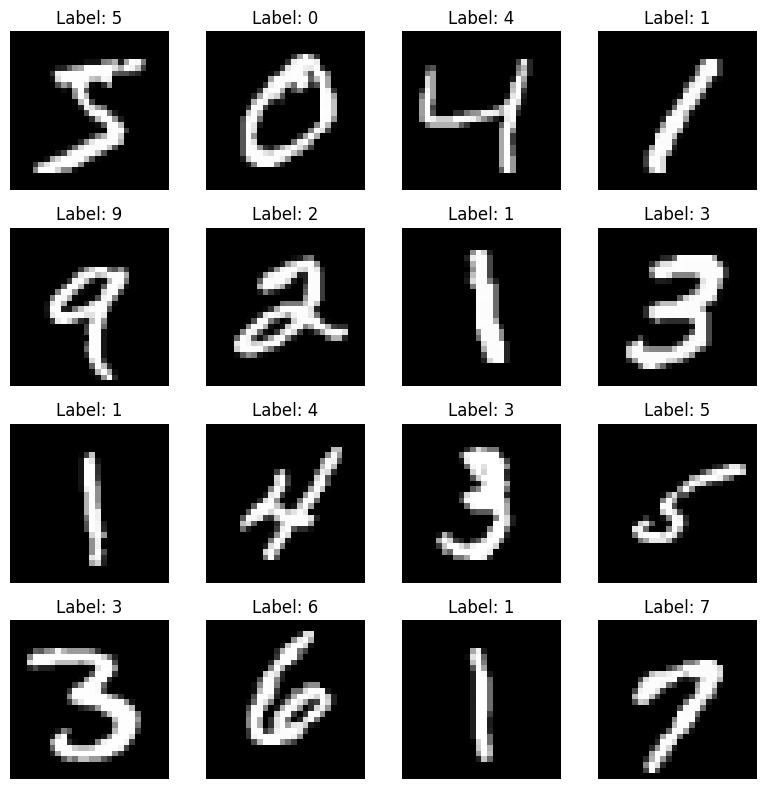

In [8]:
plt.figure(figsize=(8,8))

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. DCGAN Architecture

Build the Generator and Discriminator networks and configure the adversarial losses and optimizers.

In [9]:
LATENT_DIM = 100

### Generator Architecture

The Generator maps a random latent vector to a `28 × 28 × 1` grayscale image using dense, reshaping, and transposed convolutional layers.

In [10]:
generator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LATENT_DIM,)),

    tf.keras.layers.Dense(7 * 7 * 256, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),

    tf.keras.layers.Reshape((7, 7, 256)),

    tf.keras.layers.Conv2DTranspose(
        128,
        kernel_size=4,
        strides=2,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),

    tf.keras.layers.Conv2DTranspose(
        64,
        kernel_size=4,
        strides=2,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),

    tf.keras.layers.Conv2D(
        1,
        kernel_size=3,
        padding="same",
        activation="tanh"
    )
])

In [11]:
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,961,281 (7.48 MB)

 Trainable params: 1,935,809 (7.38 MB)

 Non-trainable params: 25,472 (99.50 KB)

### Discriminator Architecture

The Discriminator receives a `28 × 28 × 1` image and produces a single logit indicating whether the image is real or generated.

In [12]:
discriminator = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        64,
        kernel_size=4,
        strides=2,
        padding="same"
    ),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(
        128,
        kernel_size=4,
        strides=2,
        padding="same"
    ),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(
        256,
        kernel_size=4,
        strides=2,
        padding="same"
    ),
    tf.keras.layers.LeakyReLU(negative_slope=0.2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1)
])

In [13]:
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,929 (2.52 MB)

 Trainable params: 660,929 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

### GAN Losses and Optimizers

Use binary cross-entropy with logits for the adversarial losses and Adam optimizers for both networks.

In [14]:
loss_function = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

In [15]:
def discriminator_loss(real_logits, fake_logits):
    real_loss = loss_function(
        tf.ones_like(real_logits),
        real_logits
    )

    fake_loss = loss_function(
        tf.zeros_like(fake_logits),
        fake_logits
    )

    return real_loss + fake_loss

In [16]:
def generator_loss(fake_logits):
    return loss_function(
        tf.ones_like(fake_logits),
        fake_logits
    )

In [17]:
LEARNING_RATE = 0.0002
BETA_1 = 0.5

In [18]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1
)

### Architecture Verification

Verify that the Generator produces correctly shaped images and that the Discriminator produces a single logit for each image.

In [19]:
test_noise = tf.random.normal(
    shape=(16, LATENT_DIM)
)

test_fake_images = generator(
    test_noise,
    training=False
)

test_real_images = next(iter(train_dataset))[:16]

test_fake_logits = discriminator(
    test_fake_images,
    training=False
)

test_real_logits = discriminator(
    test_real_images,
    training=False
)

print("Real images shape:", test_real_images.shape)
print("Fake images shape:", test_fake_images.shape)
print("Real logits shape:", test_real_logits.shape)
print("Fake logits shape:", test_fake_logits.shape)
print(
    "Generator output range:",
    tf.reduce_min(test_fake_images).numpy(),
    "to",
    tf.reduce_max(test_fake_images).numpy()
)

I0000 00:00:1790677018.731826   71364 cuda_dnn.cc:461] Loaded cuDNN version 92400


Real images shape: (16, 28, 28, 1)
Fake images shape: (16, 28, 28, 1)
Real logits shape: (16, 1)
Fake logits shape: (16, 1)
Generator output range: -0.078670785 to 0.067175046


## 3. GAN Training

Train the Generator and Discriminator using a custom adversarial training loop.

### Custom Training Step

Perform one adversarial training step by updating the Generator and Discriminator using separate gradient calculations.

In [20]:
@tf.function
def train_step(images):

    noise = tf.random.normal(
        shape=(tf.shape(images)[0], LATENT_DIM)
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    generator_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    discriminator_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

### Fixed Latent Vectors

Use fixed random latent vectors to generate consistent samples throughout training and visualize how the Generator improves over time.

In [21]:
NUM_FIXED_SAMPLES = 16

In [22]:
fixed_noise = tf.random.normal(
    shape=(NUM_FIXED_SAMPLES, LATENT_DIM)
)

In [23]:
def generate_fixed_samples(model, noise):
    generated_images = model(
        noise,
        training=False
    )

    generated_images = (generated_images + 1.0) / 2.0

    return generated_images

### Training Configuration

Train the DCGAN for a fixed number of epochs while recording the Generator and Discriminator losses and generated samples.

In [24]:
EPOCHS = 20

generator_loss_history = []
discriminator_loss_history = []
training_samples = []

### Training Loop

Train the Generator and Discriminator alternately on each batch of real MNIST images and record the training progress after every epoch.

In [25]:
for epoch in range(EPOCHS):

    epoch_generator_losses = []
    epoch_discriminator_losses = []

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

        epoch_generator_losses.append(
            gen_loss
        )

        epoch_discriminator_losses.append(
            disc_loss
        )

    average_generator_loss = tf.reduce_mean(
        epoch_generator_losses
    ).numpy()

    average_discriminator_loss = tf.reduce_mean(
        epoch_discriminator_losses
    ).numpy()

    generator_loss_history.append(
        average_generator_loss
    )

    discriminator_loss_history.append(
        average_discriminator_loss
    )

    generated_samples = generate_fixed_samples(
        generator,
        fixed_noise
    )

    training_samples.append(
    generated_samples.numpy()
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {average_generator_loss:.4f} | "
        f"Discriminator Loss: {average_discriminator_loss:.4f}"
    )

E0000 00:00:1790677021.762204   71364 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 1/20 | Generator Loss: 0.9743 | Discriminator Loss: 1.2046
Epoch 2/20 | Generator Loss: 0.9125 | Discriminator Loss: 1.2062
Epoch 3/20 | Generator Loss: 0.9068 | Discriminator Loss: 1.2209
Epoch 4/20 | Generator Loss: 0.8464 | Discriminator Loss: 1.2626
Epoch 5/20 | Generator Loss: 0.8483 | Discriminator Loss: 1.2617
Epoch 6/20 | Generator Loss: 0.8612 | Discriminator Loss: 1.2515
Epoch 7/20 | Generator Loss: 0.8748 | Discriminator Loss: 1.2440
Epoch 8/20 | Generator Loss: 0.8829 | Discriminator Loss: 1.2420
Epoch 9/20 | Generator Loss: 0.8792 | Discriminator Loss: 1.2488
Epoch 10/20 | Generator Loss: 0.8821 | Discriminator Loss: 1.2518
Epoch 11/20 | Generator Loss: 0.8746 | Discriminator Loss: 1.2564
Epoch 12/20 | Generator Loss: 0.8724 | Discriminator Loss: 1.2606
Epoch 13/20 | Generator Loss: 0.8662 | Discriminator Loss: 1.2672
Epoch 14/20 | Generator Loss: 0.8604 | Discriminator Loss: 1.2708
Epoch 15/20 | Generator Loss: 0.8587 | Discriminator Loss: 1.2710
Epoch 16/20 | Gener

## 4. Generation and Evaluation

Generate final samples from random latent vectors and examine training progression, sample diversity, and model outputs.

In [43]:
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

In [42]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

generator.save(models_dir / "dcgan_generator.keras")
discriminator.save(models_dir / "dcgan_discriminator.keras")

print("Generator saved:", models_dir / "dcgan_generator.keras")
print("Discriminator saved:", models_dir / "dcgan_discriminator.keras")

Generator saved: models/dcgan_generator.keras
Discriminator saved: models/dcgan_discriminator.keras


### Training Losses

Visualize the Generator and Discriminator losses across training epochs.

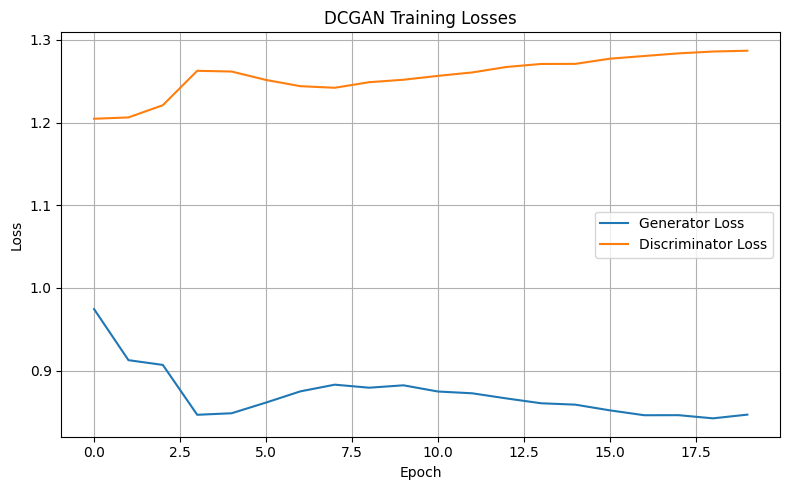

In [27]:
fig = plt.figure(figsize=(8, 5))

plt.plot(
    generator_loss_history,
    label="Generator Loss"
)

plt.plot(
    discriminator_loss_history,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Losses")
plt.legend()
plt.grid(True)

plt.tight_layout()

fig.savefig(
    output_dir / "training_losses.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### Final Image Generation

Generate a new set of handwritten digit images using random latent vectors after training.

In [28]:
NUM_FINAL_SAMPLES = 16

final_noise = tf.random.normal(
    shape=(NUM_FINAL_SAMPLES, LATENT_DIM)
)

In [29]:
final_generated_images = generator(
    final_noise,
    training=False
)

In [30]:
display_images = (
    final_generated_images + 1.0
) / 2.0

### Latent Space Sampling

Generate multiple images from independently sampled latent vectors to observe the diversity of the learned image distribution.

In [31]:
NUM_LATENT_SAMPLES = 36

latent_samples = tf.random.normal(
    shape=(NUM_LATENT_SAMPLES, LATENT_DIM)
)

print("Latent samples shape:", latent_samples.shape)

Latent samples shape: (36, 100)


In [32]:
latent_generated_images = generator(
    latent_samples,
    training=False
)

latent_generated_images = (
    latent_generated_images + 1.0
) / 2.0

print(
    "Generated images shape:",
    latent_generated_images.shape
)

Generated images shape: (36, 28, 28, 1)


### Training Progression

Compare generated samples from different training epochs to observe how image generation develops during training.

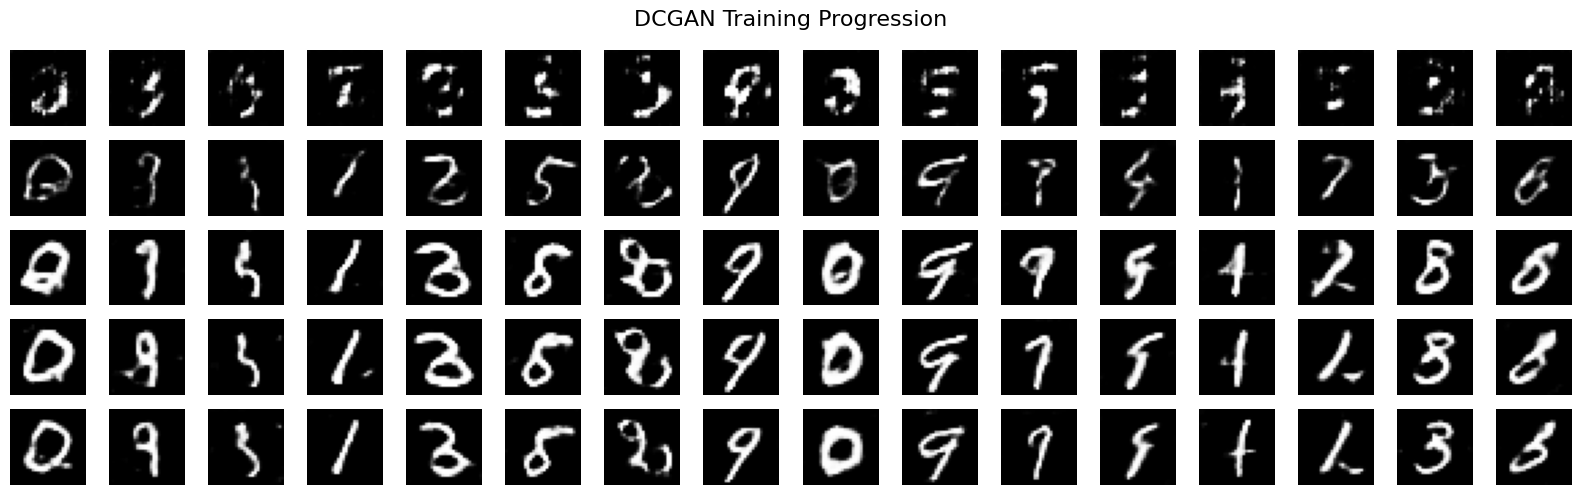

In [33]:
selected_epochs = [0, 4, 9, 14, 19]

fig, axes = plt.subplots(
    len(selected_epochs),
    16,
    figsize=(16, 5)
)

for row, epoch_index in enumerate(selected_epochs):

    for col in range(16):

        axes[row, col].imshow(
            training_samples[epoch_index][col, :, :, 0],
            cmap="gray"
        )

        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(
        f"Epoch {epoch_index + 1}",
        fontsize=11
    )

plt.suptitle(
    "DCGAN Training Progression",
    fontsize=16
)

plt.tight_layout()

fig.savefig(
    output_dir / "training_progression.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### Sample Diversity

Use pixel-level variation across generated samples as a simple quantitative indicator of output diversity.

In [34]:
flat_images = tf.reshape(
    latent_generated_images,
    [NUM_LATENT_SAMPLES, -1]
)

In [35]:
pixel_std = tf.math.reduce_std(
    flat_images,
    axis=0
)

mean_pixel_std = tf.reduce_mean(
    pixel_std
).numpy()

print(
    f"Mean pixel-wise standard deviation: "
    f"{mean_pixel_std:.4f}"
)

Mean pixel-wise standard deviation: 0.1643


In [36]:
generator_min = min(generator_loss_history)
generator_max = max(generator_loss_history)

discriminator_min = min(discriminator_loss_history)
discriminator_max = max(discriminator_loss_history)

print(
    f"Generator loss range: "
    f"{generator_min:.4f} - {generator_max:.4f}"
)

print(
    f"Discriminator loss range: "
    f"{discriminator_min:.4f} - {discriminator_max:.4f}"
)

Generator loss range: 0.8421 - 0.9743
Discriminator loss range: 1.2046 - 1.2869


### Final Generated Samples

Display and save the final images generated by the trained DCGAN.

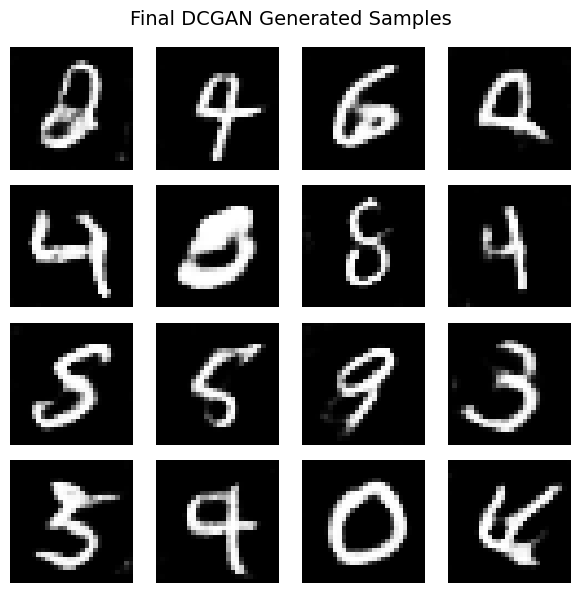

In [37]:
fig = plt.figure(figsize=(6, 6))

for i in range(NUM_FINAL_SAMPLES):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        display_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final DCGAN Generated Samples",
    fontsize=14
)

plt.tight_layout()

fig.savefig(
    output_dir / "generated_samples.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### Latent Space Samples

Display and save generated images from multiple random latent vectors.

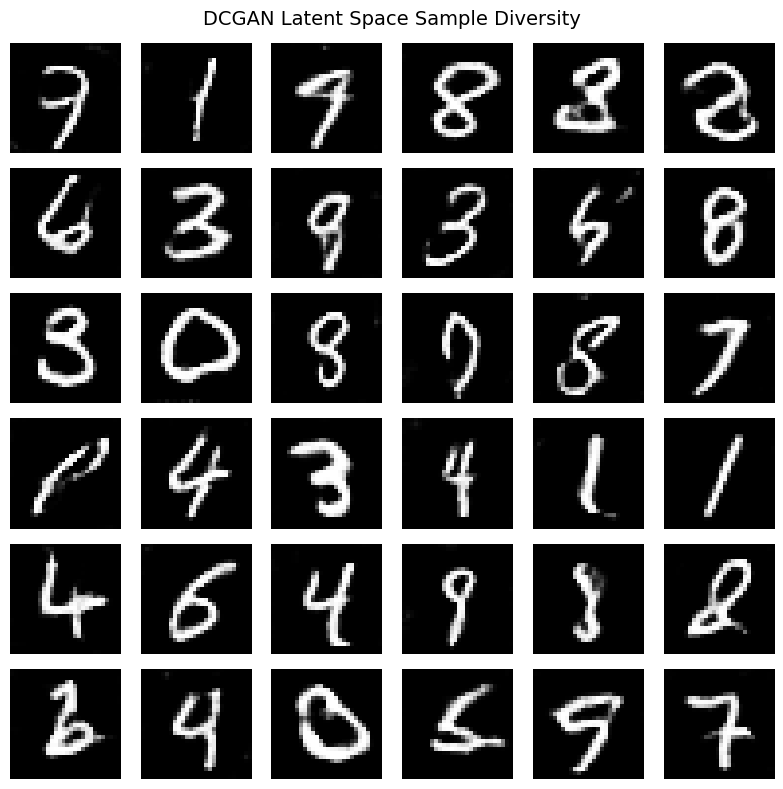

In [38]:
fig = plt.figure(figsize=(8, 8))

for i in range(NUM_LATENT_SAMPLES):

    plt.subplot(6, 6, i + 1)

    plt.imshow(
        latent_generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "DCGAN Latent Space Sample Diversity",
    fontsize=14
)

plt.tight_layout()

fig.savefig(
    output_dir / "latent_samples.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### Output Verification

Confirm that the main generated images, training progression, loss plot, and latent-space samples were saved successfully.

In [40]:
saved_files = [
    output_dir / "training_losses.png",
    output_dir / "generated_samples.png",
    output_dir / "training_progression.png",
    output_dir / "latent_samples.png"
]

for file_path in saved_files:
    print(
        file_path,
        "→",
        "Exists" if file_path.exists() else "Missing"
    )

outputs/training_losses.png → Exists
outputs/generated_samples.png → Exists
outputs/training_progression.png → Exists
outputs/latent_samples.png → Exists
